# Cuaderno para realizar el EDA del data se de prediccion de manetnimiento en maquinaria pesada

## Objetivos y preguntas claves para tener en cuenta en el analisis y la construcción del modelo

1. Enfoque de Prevención (¿Qué va a pasar?). 
* **¿Podemos identificar señales tempranas de alerta?:** Determinar si existen patrones en la temperatura o velocidad que aparecen justo antes de que una máquina falle.
* **¿Con cuánta anticipación podemos predecir una avería?:** Establecer si el modelo nos da tiempo suficiente para detener la máquina de forma controlada antes de un colapso total.

2. Enfoque de Diagnóstico (¿Por qué pasa?)
* **¿Cuáles son los "enemigos" principales de la maquinaria?:** Identificar qué variables (ej. el torque alto o el desgaste de la herramienta) tienen más peso en la ocurrencia de fallas.
* **¿Cómo afecta el uso continuo a la integridad del equipo?:** Entender la relación entre el tiempo de operación acumulado (Tool wear) y la probabilidad de un error crítico.

3. Enfoque de Decisión (¿Qué haremos al respecto?)
* **¿Cuándo es el momento óptimo para el mantenimiento?:** Encontrar el punto exacto donde es más barato cambiar una pieza que esperar a que falle y detenga la producción.
* **¿Qué máquinas requieren una revisión prioritaria?:** Clasificar los equipos según su riesgo de fallo inminente para asignar mejor el personal técnico.

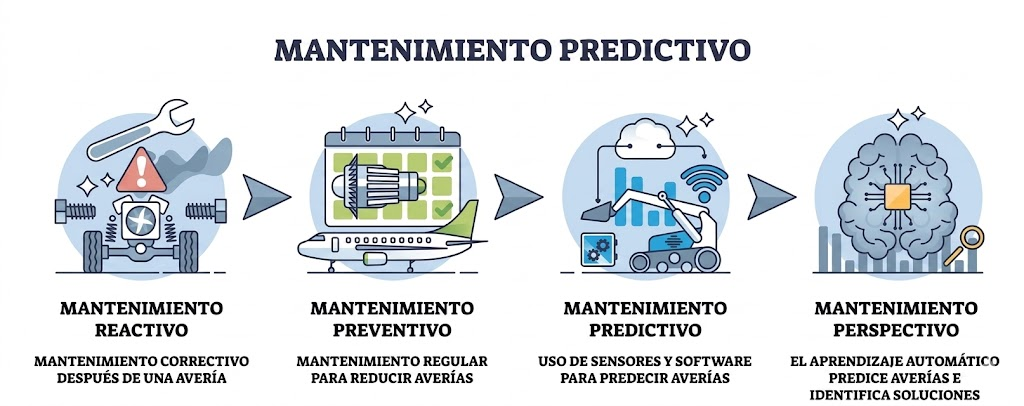

## 1. Importacion de las libreas necesarias para realizar el EDA, estas librerias ya fueron instaladas en el entorno virtual

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score

In [3]:
ruta_data = "../data/raw/ai4i2020.csv"
df_mantenimiento = pd.read_csv(ruta_data)

In [4]:
# Convierta la columna 'Type' a numérica mediante la codificación de etiquetas.
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df_mantenimiento['Type'] = le.fit_transform(df_mantenimiento['Type'])
print(df_mantenimiento['Type'].value_counts())

Type
1    6000
2    2997
0    1003
Name: count, dtype: int64


In [5]:
df_mantenimiento.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,2,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,1,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,1,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,1,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,1,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [6]:
df_mantenimiento

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,2,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,1,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,1,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,1,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,1,298.2,308.7,1408,40.0,9,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,M24855,2,298.8,308.4,1604,29.5,14,0,0,0,0,0,0
9996,9997,H39410,0,298.9,308.4,1632,31.8,17,0,0,0,0,0,0
9997,9998,M24857,2,299.0,308.6,1645,33.4,22,0,0,0,0,0,0
9998,9999,H39412,0,299.0,308.7,1408,48.5,25,0,0,0,0,0,0


In [7]:
df_mantenimiento.shape

(10000, 14)

In [8]:
df_mantenimiento.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  int64  
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(10), str(1)
m

In [9]:
df_mantenimiento.describe().T

,count,mean,std,min,25%,50%,75%,max
UDI,10000.0,5000.50000,2886.895680,1.0,2500.75,5000.5,7500.25,10000.0
Type,10000.0,1.19940,0.600230,0.0,1.00,1.0,2.00,2.0
Air temperature [K],10000.0,300.00493,2.000259,295.3,298.30,300.1,301.50,304.5
Process temperature [K],10000.0,310.00556,1.483734,305.7,308.80,310.1,311.10,313.8
Rotational speed [rpm],10000.0,1538.77610,179.284096,1168.0,1423.00,1503.0,1612.00,2886.0
Torque [Nm],10000.0,39.98691,9.968934,3.8,33.20,40.1,46.80,76.6
Tool wear [min],10000.0,107.95100,63.654147,0.0,53.00,108.0,162.00,253.0
Machine failure,10000.0,0.03390,0.180981,0.0,0.00,0.0,0.00,1.0
TWF,10000.0,0.00460,0.067671,0.0,0.00,0.0,0.00,1.0
HDF,10000.0,0.01150,0.106625,0.0,0.00,0.0,0.00,1.0


In [10]:
df_mantenimiento["Machine failure"].value_counts()

Machine failure
0    9661
1     339
Name: count, dtype: int64

In [11]:
print('\n'.join(df_mantenimiento.columns))

UDI
Product ID
Type
Air temperature [K]
Process temperature [K]
Rotational speed [rpm]
Torque [Nm]
Tool wear [min]
Machine failure
TWF
HDF
PWF
OSF
RNF


In [12]:
df_mantenimiento.isnull().sum()

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

In [13]:
df_mantenimiento["Type"].value_counts()

Type
1    6000
2    2997
0    1003
Name: count, dtype: int64

### Durante la etapa de preprocesamiento, se identificó que la variable categórica referente al tipo de maquinaria presentaba tres niveles distintivos: L (Low), M (Medium) y H (High). Para facilitar el Análisis Exploratorio de Datos (EDA) y asegurar la compatibilidad con los algoritmos de aprendizaje automático, se realizó una codificación numérica (Encoding), transformando la columna de tipo string a int64

| Categoria anterior | Categoria actual | Cantidad |
|--- | --- | --- | 
| L | 1 | 6000 |
| M | 2 | 2997 |
| H | 0 | 1003 |

In [14]:
data = df_mantenimiento.drop('Product ID', axis=1)

In [15]:
data.head()

,UDI,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,2,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,1,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,1,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,1,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,1,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [16]:
print('\n'.join(data.columns))

UDI
Type
Air temperature [K]
Process temperature [K]
Rotational speed [rpm]
Torque [Nm]
Tool wear [min]
Machine failure
TWF
HDF
PWF
OSF
RNF


## Inicio del EDA

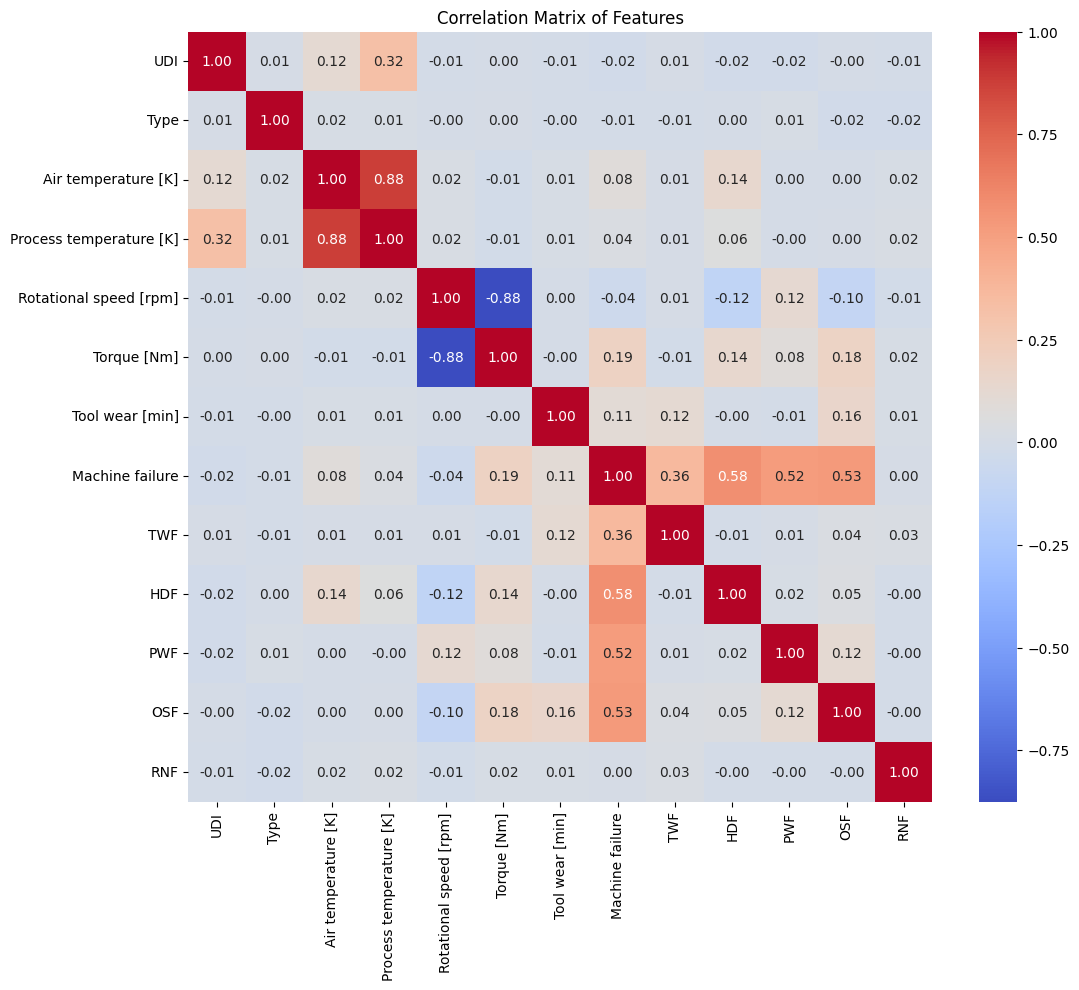

In [17]:
# Verificar la correlación entre cada punto y graficarla mediante un mapa de calor.
correlation_matrix = data.corr()

# Se procede a graficar el mapa de calor utilizando la libreria seaborn y matplotlib
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Features')
plt.show()

### Matriz de correlacion
Inicialmente se puede observar que se retira la variable product_ID, por dos motivos muy importantes:
* **Incompatibilidad Técnica:** Es una variable tipo string. Al no ser numérica, genera un error de sistema al intentar calcular la matriz.
* **Sin Valor Estadístico:** Es solo una etiqueta de identificación. No influye en el comportamiento físico de la máquina ni ayuda a predecir si fallará.

### Conclusiones de la matriz de correlacion

De esta matriz de correlacion se puede determinar lo siguiente:

* **Multicolinealidad Crítica:** Existe una correlación de 0.88 entre Air temperature y Process temperature. Son prácticamente la misma información; esto indica que se puede evitar usar una de estas variables con el fin de evitar la redundancia y optimizar recursos.
* **Relación Física Inversa:** La correlación de -0.88 entre Rotational speed y Torque confirma que cuando una sube, la otra baja drásticamente. Ambas son predictores clave.
* **Principales Causas de Falla:** Los fallos térmicos (HDF: 0.58) y por esfuerzo (OSF: 0.53) son los que más directamente explican la variable Machine failure.
* **Variables Irrelevantes:** UDI, Type y RNF tienen correlaciones cercanas a 0. No aportan valor estadístico para predecir fallas mecánicas.

### Procesos a realizar con los hallazgos que se obtuvieron del analisis de la matriz de correlaciones:

Inicialmente se eliminaran las siguientes columnas, esto dado que basados en el analisis inicial de la matriz de correlación se oberva que no aporta valor predictivo al dataset

1. **'UDI':** Es un índice secuencial, no aporta valor estadístico.
2. **'RNF':** Su correlación con las fallas es cercana a 0 (fallas aleatorias).
3. **'Air temperature [K]':** Se elimina para evitar la redundancia con 'Process temperature [K]' (correlación de 0.88).

Sin embargo tambien observamos que la variable 'Type' es una variable que no tiene correlacion con ninguna variable, pero esta variable me indica que tipo de maquina e, al quitarla le estariamos quitando al modelo contexto para evaluar el tipo de maquina.

* Esta variable permite al modelo segmentar el comportamiento de falla según la calidad de la maquinaria (L, M, H), capturando patrones específicos de operación que las variables numéricas por sí solas no logran explicar.

In [18]:
# Se define una lista de las columnas a eliminar, excluyendo la columna 'type' por lo explicado anteriormente.
variables_eliminar = ['UDI', 'RNF', 'Air temperature [K]']

data = data.drop(columns=variables_eliminar)
print("Columnas restantes en el dataset:")
print('\n'.join(data.columns))

Columnas restantes en el dataset:
Type
Process temperature [K]
Rotational speed [rpm]
Torque [Nm]
Tool wear [min]
Machine failure
TWF
HDF
PWF
OSF


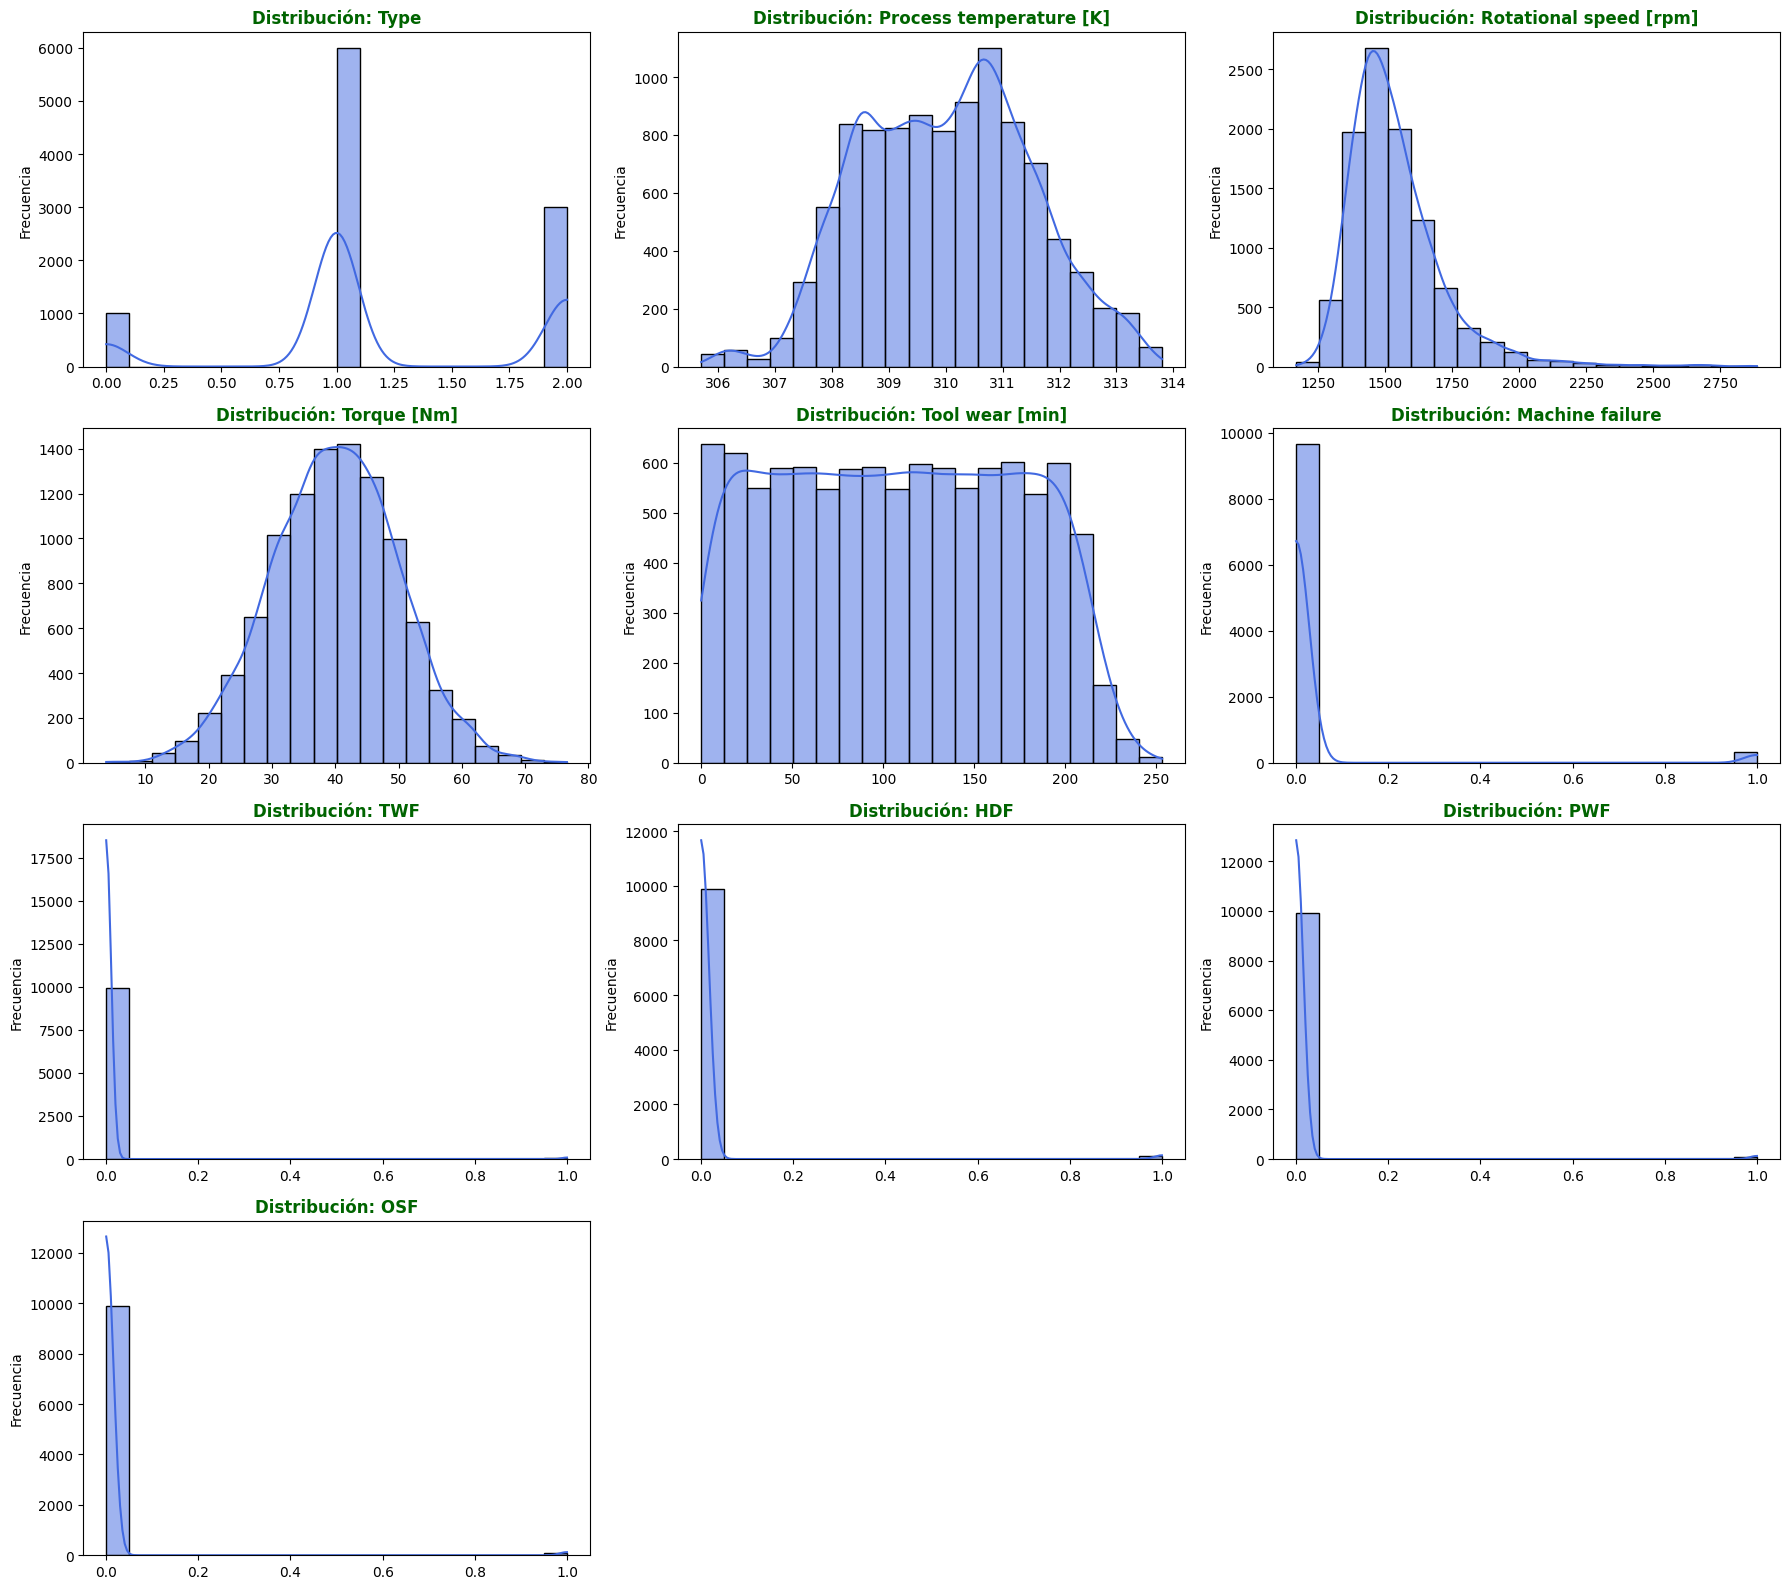

In [19]:
import math

# 1. Configuración de las columnas a graficar
# Usamos todas las columnas de tu variable 'data'
cols_to_plot = data.columns
n_cols = 3  # Queremos 3 columnas de gráficos por fila
n_rows = math.ceil(len(cols_to_plot) / n_cols)

# 2. Creamos la figura y la cuadrícula de subplots
# Ajustamos el tamaño (figsize) para que sea legible
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()  # Aplanamos los ejes para iterar fácilmente

# 3. Bucle para crear cada histograma con Seaborn
for i, col_name in enumerate(cols_to_plot):
    # Creamos el histograma con línea de densidad (KDE)
    sns.histplot(data[col_name], bins=20, ax=axes[i], color='royalblue', kde=True)
    
    # Personalización estética
    axes[i].set_title(f"Distribución: {col_name}", fontsize=12, fontweight='bold', color='darkgreen')
    axes[i].set_xlabel("") # Limpiamos el eje X para que no se vea saturado
    axes[i].set_ylabel("Frecuencia")

# 4. Limpieza de espacios vacíos
# Si el número de columnas no es múltiplo de 3, eliminamos los cuadros sobrantes
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# 5. Ajuste final y mostrar
plt.tight_layout()
plt.show()

### Conclusiones con base a las graficas:

**Con base a las graficas presentadas, se puede concluir lo siguiente:**

El análisis de distribución revela que mientras las variables térmicas y mecánicas (Torque, Temperatura) siguen un comportamiento normal, las variables de falla presentan un desbalance severo. Esto confirma la necesidad de utilizar algoritmos robustos a clases minoritarias. Además, la distribución uniforme del desgaste de herramienta asegura que el modelo será entrenado con datos de todo el ciclo de vida del componente.


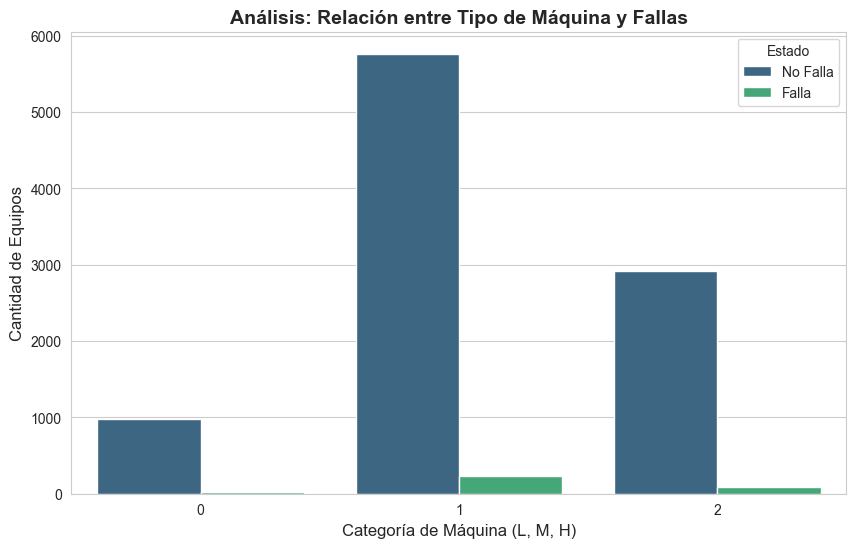

In [20]:
# 1. Configuramos el tamaño y el estilo
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid") # Agrega una cuadrícula ligera de fondo

# 2. Creamos el gráfico de conteo
# Usamos 'data' y agregamos una paleta de colores más clara
ax = sns.countplot(x='Type', hue='Machine failure', data=data, palette='viridis')

# 3. Personalización de etiquetas
plt.title('Análisis: Relación entre Tipo de Máquina y Fallas', fontsize=14, fontweight='bold')
plt.xlabel('Categoría de Máquina (L, M, H)', fontsize=12)
plt.ylabel('Cantidad de Equipos', fontsize=12)
plt.legend(title='Estado', labels=['No Falla', 'Falla'])

# 4. Mostrar el gráfico
plt.show()

### Grafica categorica

En esta grafica en la cual se evidencia la categoria a la cual pertenece cada maquina y si ha fallado o no.

En este analisis nos indica que el dataset esta desbalanceado, donde la categoría intermedia (1) predomina en volumen. La baja frecuencia de fallas visibles en todas las categorías sugiere que el tipo de máquina, por sí solo, no es un determinante lineal de falla, reforzando la importancia de realizar un análisis multivariado que incluya las variables técnicas de los sensores.

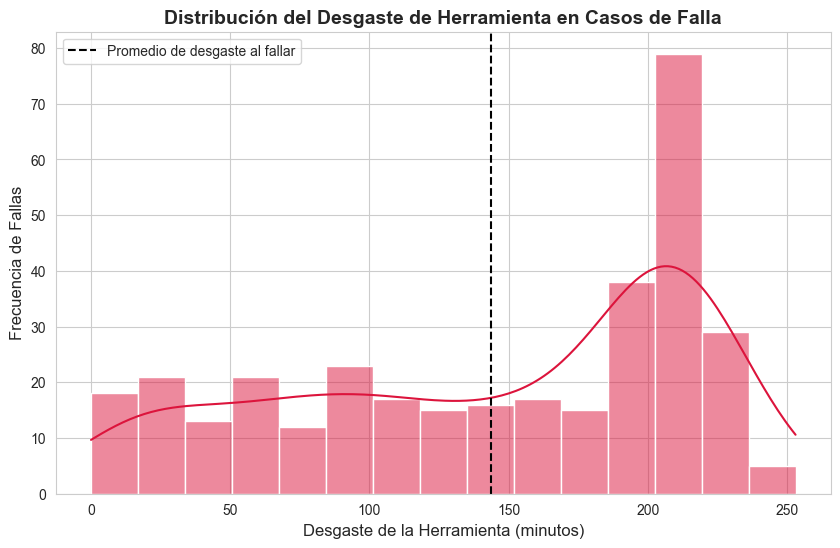

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Filtramos los datos y configuramos el lienzo
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# 2. Creamos el histograma específico para fallas
# Usamos 'data', color específico y aumentamos los bins para ver más detalle
sns.histplot(data=data[data['Machine failure'] == 1], 
             x='Tool wear [min]', 
             kde=True, 
             color='crimson', 
             bins=15)

# 3. Personalización profesional
plt.title('Distribución del Desgaste de Herramienta en Casos de Falla', fontsize=14, fontweight='bold')
plt.xlabel('Desgaste de la Herramienta (minutos)', fontsize=12)
plt.ylabel('Frecuencia de Fallas', fontsize=12)

# 4. Añadimos una línea promedio para dar contexto
plt.axvline(data[data['Machine failure'] == 1]['Tool wear [min]'].mean(), 
            color='black', linestyle='--', label='Promedio de desgaste al fallar')
plt.legend()

plt.show()

### Grafica de fallo por minutos de uso de la maquina:

La distribución de fallas respecto al desgaste de herramienta muestra una concentración crítica por encima de los 200 minutos. Mientras que las fallas antes de los 150 minutos parecen ser aleatorias, el incremento sustancial al final del espectro confirma que el 'Tool Wear' es un predictor determinante para el fallo del equipo, permitiendo establecer ventanas de mantenimiento preventivo antes de alcanzar el umbral de los 200 minutos.

### Eliminacion de columnas adicionales:

Para evitar la "fuga de datos" (Data Leakage): la finalidad del modelo, es predecir si la maquina falla, o en cuanto tiempo fallaria, que en este caso seria la columna 'Machine failure', por lo tanto para que este modelo sea optimo, estas columnas no pueden estar

Esto se debe, a que se debe dejar unicamente datos de sensores, para que el modelo tenga la capidad de predecir.

In [22]:
data = data.drop(['TWF', 'HDF', 'PWF', 'OSF'], axis=1)

In [23]:
data.head()

,Type,Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure
0,2,308.6,1551,42.8,0,0
1,1,308.7,1408,46.3,3,0
2,1,308.5,1498,49.4,5,0
3,1,308.6,1433,39.5,7,0
4,1,308.7,1408,40.0,9,0


### Division del dataset para el entrenamiento

En esta parte del EDA, se divide el dataset para realizar el entrenamiento del modelo

* **X:** Se selecciona todos los datos de los sensores, y se quita la variable o columna 'Machine failure'
* **y:** Se selecciona unicamente la variable 'Machine failure', que esta sera la variable objetivo

In [24]:
X = data.drop(["Machine failure"], axis = 1)
y = data["Machine failure"] # columna objetivo


In [25]:
from imblearn.over_sampling import RandomOverSampler
oversample = RandomOverSampler(sampling_strategy='minority', random_state = 1)

In [26]:
X1,y1 = oversample.fit_resample(X, y)# Balanceando la variable dependiente (y) y la variable independiente (X)."

In [27]:
# 1. y1.value_counts() cuenta cuántos 0s y cuántos 1s hay ahora en tus respuestas
# 2. pd.DataFrame(...) envuelve esos conteos en una tabla (DataFrame) para que se vea ordenado
overdf = pd.DataFrame(y1.value_counts())

# Mostramos la tabla resultante para confirmar que ambas clases (0 y 1) tienen la misma cantidad
overdf

,count
Machine failure,
0,9661
1,9661


In [28]:
# Dividimos los datos balanceados (X1, y1) en cuatro grupos:
# 1. x_train: Datos de los sensores para entrenar (el estudio).
# 2. x_test: Datos de los sensores para evaluar (el examen).
# 3. y_train: Respuestas (fallas) para el entrenamiento.
# 4. y_test: Respuestas reales para calificar el examen del modelo.

x_train, x_test, y_train, y_test = train_test_split(
    X1,              # Tus variables independientes balanceadas
    y1,              # Tu variable objetivo balanceada
    test_size=0.2,   # Separamos el 20% de los datos para el examen final
    random_state=42  # Semilla para que la división sea siempre la misma
)

# Inicio de la creacion y ejecucion de los modelos

## Inicialmente se importan librerias adicionales para la ejecución de los modelos

### Clase para evaluar modelos
Para poder evaluar diferentes modelos de una manera mas optima sin repetir tanto codigo se tiene lo siguiente

Con la estructura del codigo, permite comparar diferentes modelos de una manera mas opcioma

In [29]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import cross_val_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve

In [30]:
class ModelEvaluation:
    # Diccionario para guardar los resultados de todos los modelos que pruebes
    scores = {'Model':[], 'Accuracy':[], 'CV_Score':[], 'auc':[]}

    def __init__(self, model, model_name):
        self.model = model
        self.model_name = model_name

    def run_pipeline(self, x_train, y_train, x_test, y_test):
        # 1. Entrenamos el modelo
        self.model.fit(x_train, y_train)
        
        # 2. Hacemos predicciones
        pred = self.model.predict(x_test)
        
        # 3. Calculamos métricas avanzadas
        # El Cross Validation ayuda a saber si el modelo es estable o tuvo suerte
        cv_score = np.mean(cross_val_score(self.model, x_test, y_test, cv=5))
        auc = roc_auc_score(y_test, pred)
        fpr, tpr, _ = roc_curve(y_test, pred)

        # 4. Mostramos resultados
        self.display_performance(pred, y_test, cv_score, auc)
        self.plot_roc_curve(fpr, tpr)

    def display_performance(self, pred, y_actual, cv_score, auc):
        accuracy = accuracy_score(y_actual, pred)

        # Guardamos en el diccionario global de la clase
        ModelEvaluation.scores['Model'].append(self.model_name)
        ModelEvaluation.scores['Accuracy'].append(accuracy)
        ModelEvaluation.scores['CV_Score'].append(cv_score)
        ModelEvaluation.scores['auc'].append(auc)

        print(f'--- Reporte de: {self.model_name} ---')
        print(f'Accuracy Score: {accuracy:.4f}')
        print(f'Mean Cross Validation Score: {cv_score:.4f}\n')
        print(f'Classification Report:\n{classification_report(y_actual, pred)}')

        self.plot_confusion_matrix(y_actual, pred)

    def plot_confusion_matrix(self, y_actual, pred):
        plt.figure(figsize=(6,4))
        cm = confusion_matrix(y_actual, pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap="YlGnBu")
        plt.title(f'Matriz de Confusión: {self.model_name}')
        plt.ylabel('Realidad')
        plt.xlabel('Predicción')
        plt.show()

    def plot_roc_curve(self, fpr, tpr):
        plt.figure(figsize=(6,4))
        plt.plot(fpr, tpr, color='orange', label=f'ROC (AUC = {ModelEvaluation.scores["auc"][-1]:.2f})')
        plt.plot([0, 1], [0, 1], color='darkblue', linestyle='--')
        plt.xlabel('Tasa de Falsos Positivos (FPR)')
        plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
        plt.title('Curva ROC')
        plt.legend()
        plt.show()

### Codigo modelo Regresion lineal

--- Reporte de: Logistic Regression ---
Accuracy Score: 0.7690
Mean Cross Validation Score: 0.7684

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.81      0.78      1934
           1       0.79      0.73      0.76      1931

    accuracy                           0.77      3865
   macro avg       0.77      0.77      0.77      3865
weighted avg       0.77      0.77      0.77      3865



c:\Users\lufeb\project_IA\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\lufeb\project_IA\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html


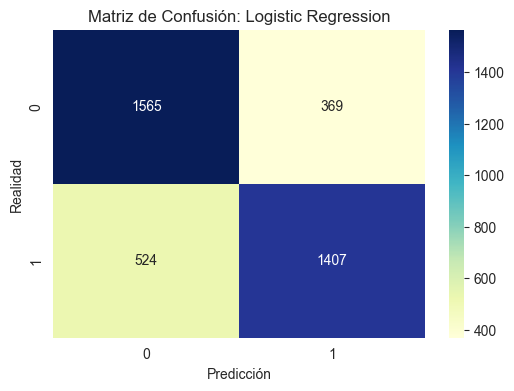

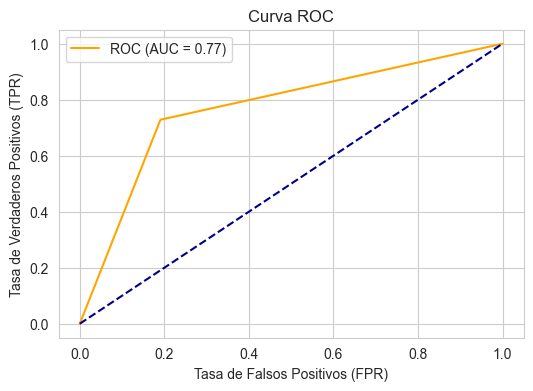

In [31]:
# 1. Importamos el algoritmo
from sklearn.linear_model import LogisticRegression

# 2. Creamos la instancia con la clase mejorada
# Pasamos el algoritmo y el nombre descriptivo
lr_analysis = ModelEvaluation(LogisticRegression(random_state=20), 'Logistic Regression')

# 3. Ejecutamos todo el proceso pasando nuestros datos balanceados
# Recuerda que usamos X1 e y1 que son los datos que pasaron por el oversampling
lr_analysis.run_pipeline(x_train, y_train, x_test, y_test)

#### **Conclusiones Modelo de Regresion lineal**

1. Interpretación de la Matriz de Confusión
La matriz nos muestra exactamente qué tan bien "adivinó" el modelo en el set de prueba:

* **Verdaderos Positivos (1407):** El modelo identificó correctamente 1407 máquinas que realmente fallaron.
* **Verdaderos Negativos (1565):** Identificó correctamente 1565 máquinas que operaban normalmente.
* **Falsos Negativos (524):** ¡Cuidado aquí! Estas son máquinas que fallaron, pero el modelo dijo que estaban bien. En mantenimiento predictivo, este es el error más costoso.
* **Falsos Positivos (369):** El modelo dijo que fallarían, pero estaban bien (falsas alarmas).

2. Métricas de Desempeño

* **Accuracy (76.90%):** El modelo acierta casi 8 de cada 10 veces. Es un buen comienzo para un modelo lineal simple.
* **Cross Validation (76.84%):** Esta es la mejor noticia. Como el puntaje de CV es casi idéntico al Accuracy, sabemos que el modelo no tiene sobreajuste (overfitting). Es muy estable y se comportará igual con datos nuevos.
* **F1-Score (0.76 - 0.78):** Al estar por encima de 0.70, nos indica que el modelo tiene un buen equilibrio entre detectar fallas y no lanzar demasiadas falsas alarmas.

3. **Curva ROC (AUC = 0.77):** El valor de 0.77 es bastante aceptable. Significa que hay un 77% de probabilidad de que el modelo sea capaz de distinguir correctamente entre una máquina que va a fallar y una que no. Generalmente, buscamos estar por encima de 0.80 para modelos industriales, pero para ser una Regresión Logística, es un resultado muy digno.

#### **Conclusion regresion logistica:**
* El modelo de Regresión Logística presenta un desempeño sólido y equilibrado con una precisión del 76.9%. La consistencia entre el Accuracy y el Cross Validation Score demuestra que el modelo es altamente generalizable y estable.

* Aunque logra identificar la mayoría de las fallas, todavía presenta un margen de 524 falsos negativos, lo que sugiere que algunos patrones de falla complejos (no lineales) podrían estar escapando a este algoritmo.

### Codigo modelo KNN Vecinos mas cercanos

--- Reporte de: KNN ---
Accuracy Score: 0.9713
Mean Cross Validation Score: 0.9066

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.94      0.97      1934
           1       0.95      1.00      0.97      1931

    accuracy                           0.97      3865
   macro avg       0.97      0.97      0.97      3865
weighted avg       0.97      0.97      0.97      3865



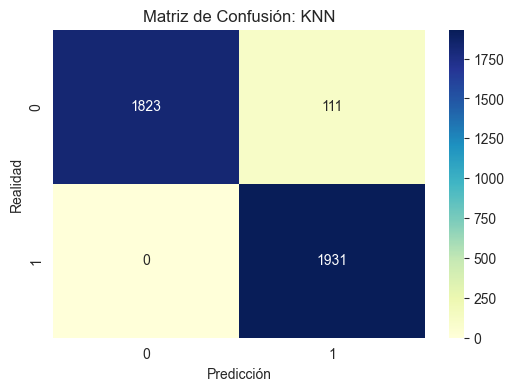

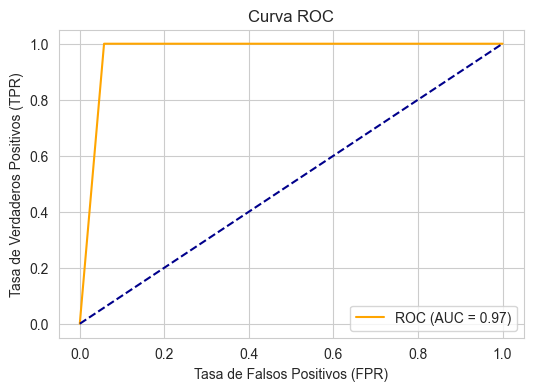

In [32]:
# 1. Importamos el algoritmo de Vecinos Cercanos
from sklearn.neighbors import KNeighborsClassifier

# 2. Creamos la instancia del evaluador
# Por defecto KNN usa 5 vecinos, pero puedes ajustarlo si quieres
knn_analysis = ModelEvaluation(KNeighborsClassifier(), 'KNN')

# 3. Ejecutamos el pipeline completo con los datos balanceados (X1, y1)
knn_analysis.run_pipeline(x_train, y_train, x_test, y_test)

#### Conclusiones modelo KNN - Vecinos mas cercanos

1. Análisis de la Matriz de Confusión. Esta matriz es casi perfecta, pero tiene una particularidad:

Falsos Negativos (0): ¡Increíble! El modelo no dejó pasar ni una sola falla. Todas las máquinas que realmente fallaron fueron detectadas. Para mantenimiento predictivo, este es el "escenario ideal".

Falsos Positivos (111): Hubo 111 casos donde el modelo dijo que fallaría y no fue así. Es un margen de error muy bajo.

2. El fenómeno del Overfitting (Sobreajuste). Aquí es donde debemos ser precavidos. Fíjate en la diferencia de estos dos números:

Accuracy Score: 97.13%

Mean Cross Validation Score: 90.66%

Hay una diferencia de casi 7 puntos. Cuando el Accuracy es mucho más alto que el Cross Validation, significa que el modelo se "memorizó" un poco los datos de entrenamiento (overfitting). KNN es muy propenso a esto porque, al duplicar datos con el Oversampling que hicimos antes, el modelo está encontrando a sus propios "clones" como vecinos más cercanos.

3. Curva ROC (AUC = 0.97): Un AUC de 0.97 es excelente. La curva sube casi verticalmente, lo que indica que el modelo tiene una capacidad casi perfecta para separar las máquinas sanas de las defectuosas.

#### Conclusion modelo KNN - Vecinos mas cercanos

El algoritmo KNN ha demostrado una capacidad superior para capturar patrones complejos, logrando detectar el 100% de las fallas en el conjunto de prueba (cero falsos negativos). Esto lo posiciona como un candidato ideal para evitar paradas de planta no programadas.

Sin embargo, se observa un ligero indicio de sobreajuste, dado que el Cross Validation (90.6%) es inferior al Accuracy (97%). Esta brecha sugiere que el modelo es muy sensible a la duplicación de datos realizada durante el balanceo. A pesar de esto, un desempeño real superior al 90% sigue siendo excelente para una implementación de mantenimiento predictivo.

### Codigo modelo Arboles de decisión

--- Reporte de: Decision Tree ---
Accuracy Score: 0.9904
Mean Cross Validation Score: 0.9671

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99      1934
           1       0.98      1.00      0.99      1931

    accuracy                           0.99      3865
   macro avg       0.99      0.99      0.99      3865
weighted avg       0.99      0.99      0.99      3865



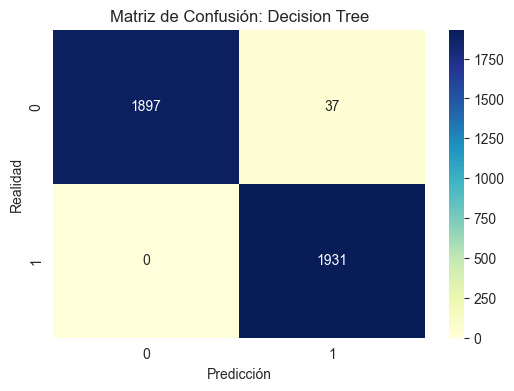

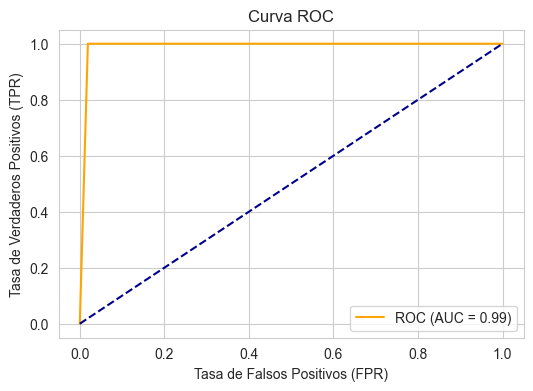

In [33]:
# 1. Importamos el algoritmo de Árbol de Decisión
from sklearn.tree import DecisionTreeClassifier

# 2. Creamos la instancia del evaluador
# Usamos random_state=20 para que los resultados sean siempre iguales
dt_analysis = ModelEvaluation(DecisionTreeClassifier(random_state=20), 'Decision Tree')

# 3. Ejecutamos el pipeline con tus datos balanceados
dt_analysis.run_pipeline(x_train, y_train, x_test, y_test)

#### Conclusiones modelo de Arbol de desición 

1. Análisis de la Matriz de Confusión. Es la matriz más limpia que hemos visto hasta ahora:

* Falsos Negativos (0): Al igual que KNN, el árbol detectó el 100% de las máquinas que fallaron. No se le escapó ninguna.

* Falsos Positivos (37): Solo hubo 37 falsas alarmas de casi 4,000 pruebas. Es un margen de error mínimo que cualquier empresa aceptaría con gusto.

* Verdaderos Positivos (1931) y Negativos (1897): La diagonal principal domina totalmente, lo que indica una clasificación casi perfecta.

2. Estabilidad y Generalización

Lo más rescatable aquí es el Mean Cross Validation Score (96.71%). A diferencia de KNN, donde la brecha era más grande, aquí el árbol demuestra que no solo está memorizando, sino que realmente ha aprendido reglas lógicas que funcionan en diferentes grupos de datos. Una puntuación de CV por encima del 96% es sinónimo de un modelo altamente confiable para ser usado en la vida real.

3. Curva ROC (AUC = 0.99). Un AUC de 0.99 es el "estándar de oro". Visualmente, la curva sube casi recta hasta el 1.0, lo que significa que el modelo separa las clases con una precisión casi absoluta.

#### Conclusion modelo de Arbol de desición

El Árbol de Decisión se posiciona como el mejor modelo hasta el momento, logrando un equilibrio excepcional entre precisión (99.04%) y estabilidad (96.71% en Cross Validation). Su capacidad para identificar todas las fallas sin excepción (cero falsos negativos) lo convierte en la herramienta más segura para prevenir daños catastróficos en los equipos

### Codigo modelo Bosque Aleatorio

--- Reporte de: Random Forest ---
Accuracy Score: 0.9946
Mean Cross Validation Score: 0.9638

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99      1934
           1       0.99      1.00      0.99      1931

    accuracy                           0.99      3865
   macro avg       0.99      0.99      0.99      3865
weighted avg       0.99      0.99      0.99      3865



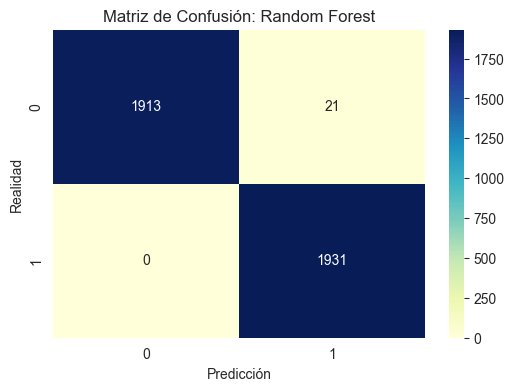

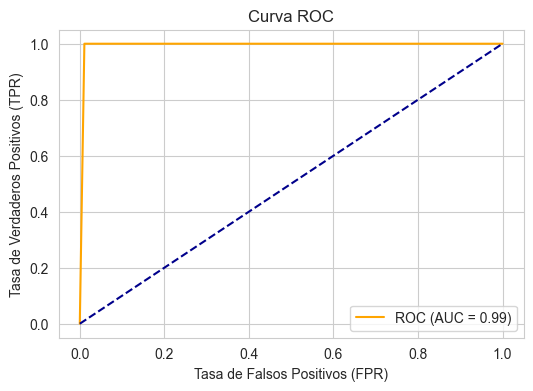

In [34]:
# 1. Importamos el algoritmo de Bosque Aleatorio
from sklearn.ensemble import RandomForestClassifier

# 2. Creamos la instancia del evaluador
# n_estimators=100 significa que usaremos 100 árboles trabajando juntos
rf_analysis = ModelEvaluation(RandomForestClassifier(n_estimators=100, random_state=20), 'Random Forest')

# 3. Ejecutamos el pipeline con tus datos balanceados
rf_analysis.run_pipeline(x_train, y_train, x_test, y_test)

#### Conclusiones modelo Bosque Aleatorio

1. Superioridad en la Matriz de Confusión. Si comparamos con el Árbol de Decisión individual, el Bosque Aleatorio mejoró notablemente:

* Falsos Negativos (0): Se mantiene la perfección. El modelo es un "guardián" impecable; ninguna falla pasó desapercibida.

* Falsos Positivos (21): ¡Bajamos de 37 a solo 21! Esto significa que el modelo es mucho más preciso y genera menos falsas alarmas que todos los anteriores.

* Verdaderos Positivos (1931) y Negativos (1913): Casi la totalidad de las muestras están en la diagonal del éxito.

2. Estabilidad Comprobada (Cross Validation). Con un 99.46% de Accuracy y un 96.38% de CV Score, tenemos un modelo que no solo es increíblemente preciso, sino que también es confiable. Al ser un "ensamble" (muchos modelos en uno), el Random Forest es mucho menos propenso a fallar cuando le entregues datos reales de la planta que no ha visto nunca.

3. Curva ROC (AUC = 0.99). Visualmente, el modelo es casi perfecto. El área bajo la curva de 0.99 confirma que la separación entre máquinas sanas y fallidas es prácticamente absoluta.

#### Conclusion modelo Bosque Aleatorio

El modelo de Random Forest es la solución definitiva para este sistema de mantenimiento predictivo. Con una precisión del 99.46% y la capacidad de detectar el 100% de los eventos de falla, garantiza una reducción máxima de costos por paradas no programadas.

Al minimizar las falsas alarmas (solo 21 casos), este algoritmo optimiza también el tiempo del personal de mantenimiento, evitando inspecciones innecesarias. Es el modelo con mejor desempeño técnico y estabilidad estadística de todo el estudio.

## Tabla comparativo de los modelos ejecutados

In [35]:
# 1. Convertimos el diccionario de nuestra clase mejorada en un DataFrame
# Usamos ModelEvaluation.scores que es donde se guardaron los resultados
performance = pd.DataFrame(ModelEvaluation.scores)

# 2. Ordenamos por Accuracy de mayor a menor para ver al ganador arriba
performance.sort_values(by='Accuracy', ascending=False, inplace=True)

# 3. Limpiamos los índices para que la tabla se vea profesional (0, 1, 2...)
performance.reset_index(drop=True, inplace=True)

# 4. Mostramos el cuadro de honor de tus modelos
performance

,Model,Accuracy,CV_Score,auc
0,Random Forest,0.994567,0.963777,0.994571
1,Decision Tree,0.990427,0.967141,0.990434
2,KNN,0.971281,0.906598,0.971303
3,Logistic Regression,0.768952,0.768435,0.768921


### Conclusion tabla modelos ejecutados

El análisis demuestra una evolución clara en la capacidad de aprendizaje, donde los modelos basados en árboles superaron significativamente a los modelos lineales y de vecinos.

* El Ganador Indiscutible: El Random Forest se consolida como la mejor opción para el proyecto. No solo alcanzó la precisión más alta (99.46%), sino que logró reducir las falsas alarmas (falsos positivos) a su nivel más bajo, manteniendo una detección de fallas del 100%.

* Estabilidad Superior: A diferencia de KNN, que mostró signos de memorización excesiva, el Random Forest mantuvo un CV_Score robusto. Esto significa que cuando el modelo se importa a una aplicacion de uso real, el modelo seguirá siendo confiable y no fallará por "sorpresa".

* Decisión Técnica: Por su equilibrio entre precisión casi perfecta y estabilidad estadística, el Random Forest es el modelo que debe ser exportado y utilizado en tu interfaz de usuario final.

# Uso de la libreria Joblib 

In [ ]:
import joblib

# 1. Definimos ruta y nombre del archivo donde guardaremos el modelo ganador
ruta_carpeta = 'src/models'
nombre_archivo = 'modelo_mantenimiento_predictivo.joblib'
ruta_completa = os.path.join(ruta_carpeta, nombre_archivo)

# 2. Guardamos el modelo ganador
# En este caso, rf_analysis.model es el objeto que contiene el Random Forest entrenado
joblib.dump(rf_analysis.model, ruta_completa)

print(f"✅ ¡Éxito! El modelo ha sido guardado como: {nombre_archivo}")

✅ ¡Éxito! El modelo ha sido guardado como: modelo_mantenimiento_predictivo.joblib


In [37]:
# Cargar el modelo guardado
modelo_cargado = joblib.load('modelo_mantenimiento_predictivo.joblib')

# prediccion = modelo_cargado.predict(nuevos_datos_sensores)

In [41]:
ruta_data = "../data/procesado/"
data.to_parquet(f'{ruta_data}mantenimiento_limpio.parquet', index=False)